Saving 21.1.xlsx to 21.1 (6).xlsx
Prueba ADF:
Estadístico ADF: -0.4674
p-valor: 0.8982
Interpretación: La serie es no estacionaria.



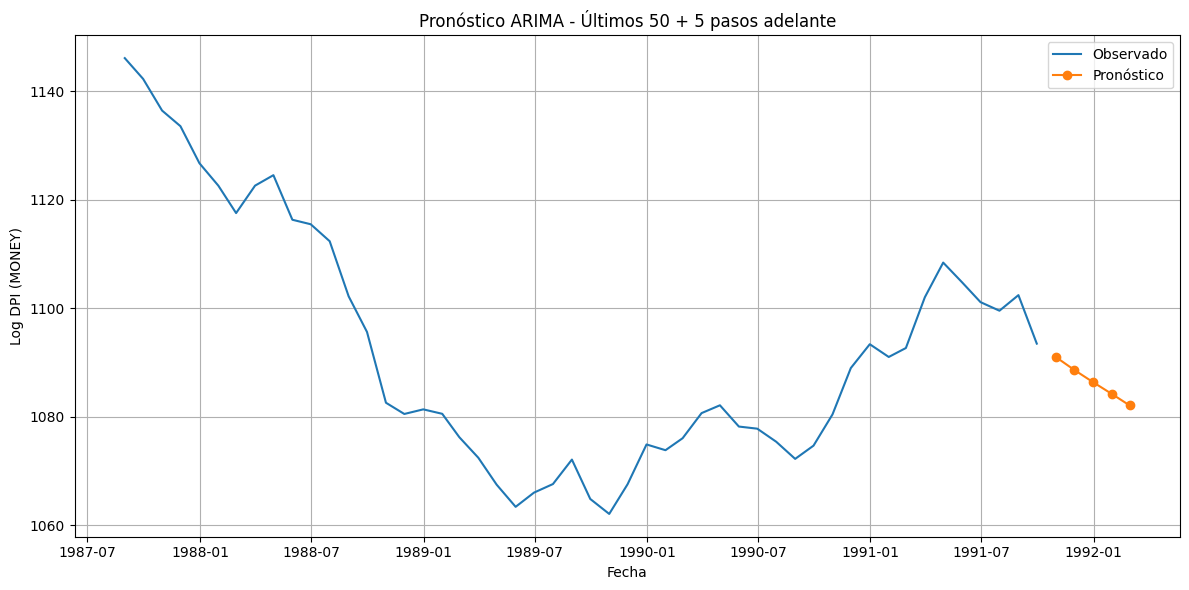


Código fuente del modelo ARIMA:

class ARIMA(sarimax.SARIMAX):
    r"""
    Autoregressive Integrated Moving Average (ARIMA) model, and extensions

    This model is the basic interface for ARIMA-type models, including those
    with exogenous regressors and those with seasonal components. The most
    general form of the model is SARIMAX(p, d, q)x(P, D, Q, s). It also allows
    all specialized cases, including

    - autoregressive models: AR(p)
    - moving average models: MA(q)
    - mixed autoregressive moving average models: ARMA(p, q)
    - integration models: ARIMA(p, d, q)
    - seasonal models: SARIMA(P, D, Q, s)
    - regression with errors that follow one of the above ARIMA-type models

    Parameters
    ----------
    endog : array_like, optional
        The observed time-series process :math:`y`.
    exog : array_like, optional
        Array of exogenous regressors.
    order : tuple, optional
        The (p,d,q) order of the model for the autoregressive, differences, a

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
# Paso 1: Librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from google.colab import files
from IPython.display import display, HTML
import base64
from io import BytesIO
import warnings
warnings.filterwarnings("ignore")

# Paso 2: Subir archivo
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# Paso 3: Leer datos
df = pd.read_excel(file_name, sheet_name="Example 21.1")
series = df['MONEY'].dropna()

# Paso 4: Índice de tiempo mensual desde enero de 1951
index = pd.date_range(start='1951-01-01', periods=len(series), freq='M')
series.index = index

# Paso 5: Prueba de Dickey-Fuller (ADF)
adf_result = adfuller(series)
adf_stat = adf_result[0]
p_value = adf_result[1]
adf_interp = "Estacionaria" if p_value < 0.05 else "No estacionaria"

# Mostrar resultados ADF
print("Prueba ADF:")
print(f"Estadístico ADF: {adf_stat:.4f}")
print(f"p-valor: {p_value:.4f}")
print(f"Interpretación: La serie es {adf_interp.lower()}.\n")

# Paso 6: Modelado ARIMA si no es estacionaria
if p_value >= 0.05:
    model = ARIMA(series, order=(1,1,1))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=5)
else:
    model = ARIMA(series, order=(1,0,1))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=5)

# Paso 7: Gráfico
plt.figure(figsize=(12,6))
plt.plot(series[-50:], label='Observado')
plt.plot(pd.date_range(series.index[-1]+pd.offsets.MonthBegin(), periods=5, freq='M'),
         forecast, label='Pronóstico', marker='o')
plt.title('Pronóstico ARIMA - Últimos 50 + 5 pasos adelante')
plt.xlabel('Fecha')
plt.ylabel('Log DPI (MONEY)')
plt.legend()
plt.grid()
plt.tight_layout()

# Guardar imagen
img_buffer = BytesIO()
plt.savefig(img_buffer, format='png')
img_buffer.seek(0)
img_base64 = base64.b64encode(img_buffer.read()).decode('utf-8')
plt.show()

# Paso 8: Código fuente mostrado
import inspect
codigo_modelo = inspect.getsource(model.__class__)
print("\nCódigo fuente del modelo ARIMA:\n")
print(codigo_modelo[:2000] + "\n...")  # Mostramos solo los primeros 2000 caracteres

# Paso 9: Generar HTML con resultados
html = f"""
<html>
<head><meta charset="utf-8"><title>Reporte ARIMA</title></head>
<body>
<h2>Ejercicio - Análisis ARIMA</h2>
<h3>Resultado Prueba ADF</h3>
<p><strong>Estadístico ADF:</strong> {adf_stat:.4f}</p>
<p><strong>p-valor:</strong> {p_value:.4f}</p>
<p><strong>Interpretación:</strong> La serie es <strong>{adf_interp.lower()}</strong>.</p>
<h3>Pronóstico a 5 pasos</h3>
<ol>
{''.join([f"<li>{val:.4f}</li>" for val in forecast])}
</ol>
<h3>Gráfico</h3>
<img src="data:image/png;base64,{img_base64}" style="width:80%;border:1px solid #ccc;">
</body>
</html>
"""

# Guardar archivo HTML
with open("reporte_arima.html", "w", encoding="utf-8") as f:
    f.write(html)

# Descargar automáticamente
files.download("reporte_arima.html")
